# Curriculum Learning Visualization
This notebook generates a 3D visualization of the `CurriculumSampler` logic used in the training pipeline, showing how the model's 'attention window' for mathematical complexity shifts and widens over time.

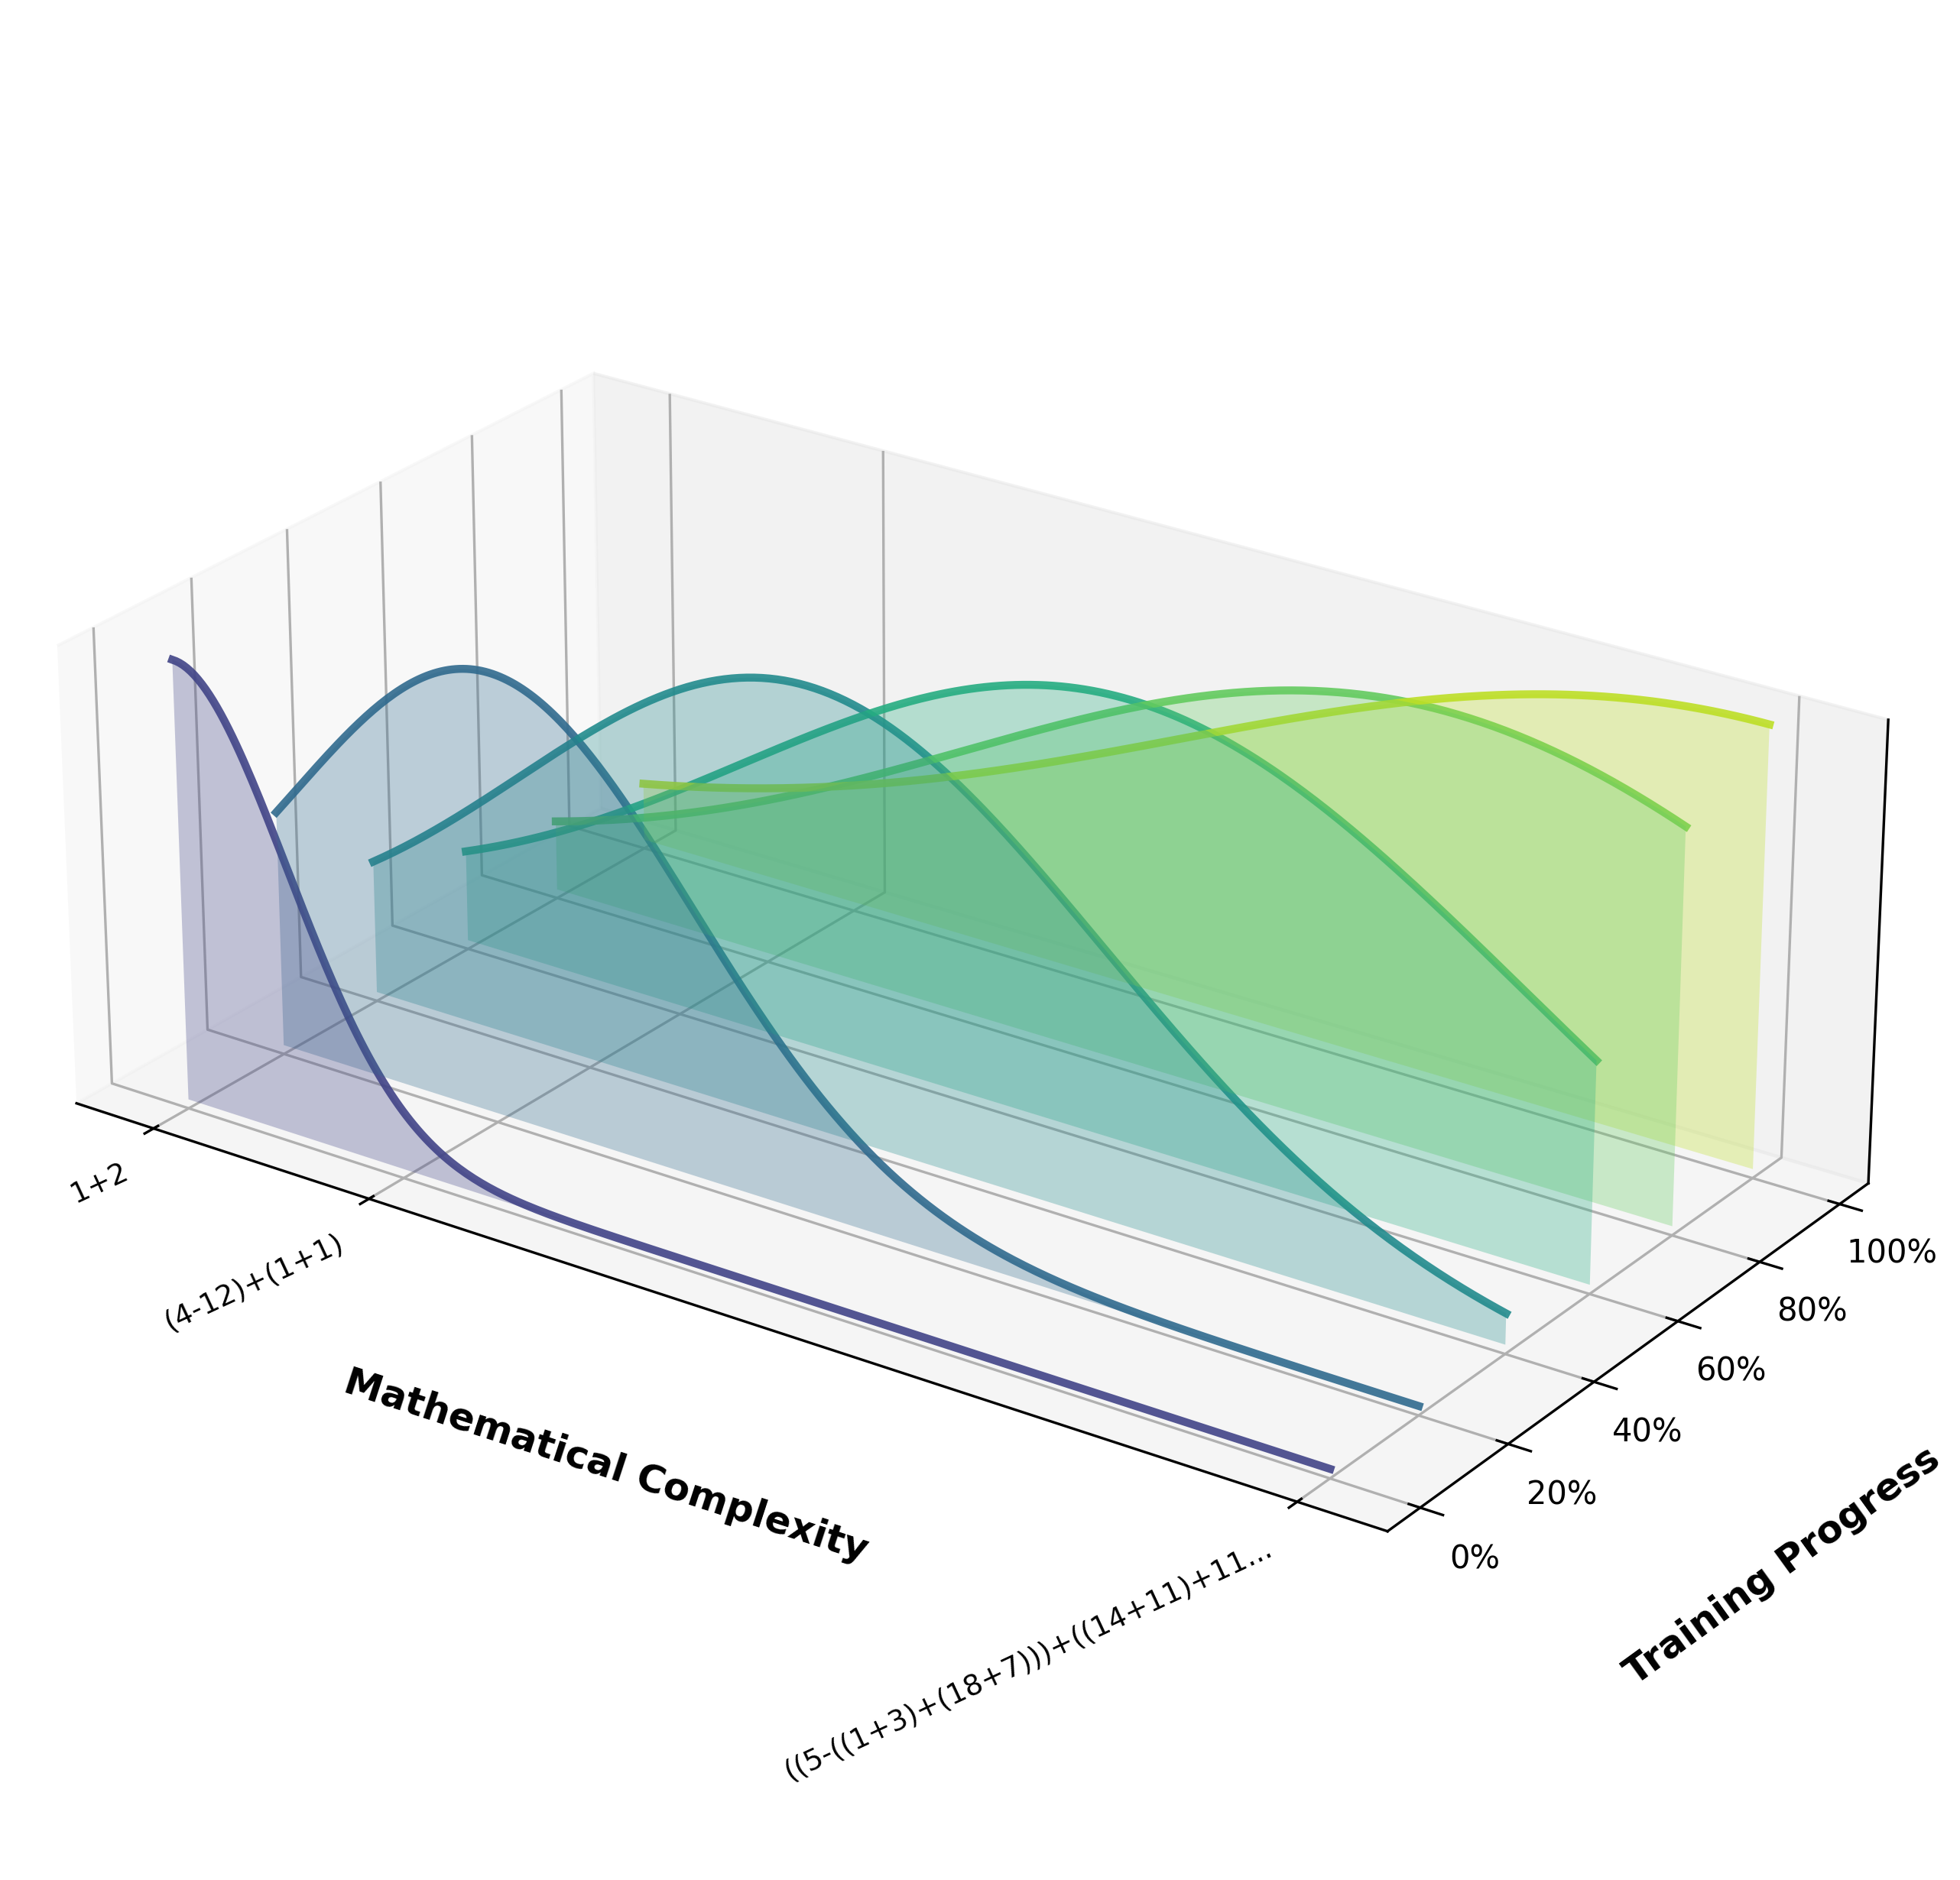

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mpl_toolkits.mplot3d.art3d as art3d
from matplotlib import cm

# Set up the complexity axis (X: 0 to 1)
x = np.linspace(0, 1, 300)

# Set up the training progress axis (Z: 0 to 1, representing Epochs/Steps)
progress_steps = np.linspace(0, 1.0, 6) # 6 snapshots in time (0% to 100%)

fig = plt.figure(figsize=(10, 10), facecolor='white', dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Stretch the X-axis to be longer
try:
    ax.set_box_aspect((2.5, 1.4, 0.8)) # X, Y, Z aspect ratio
except AttributeError:
    pass # Fallback for older matplotlib

# Zoom out slightly to stop cropping
try:
    ax.view_init(elev=25, azim=-55, zoom=0.85)
except TypeError:
    ax.view_init(elev=25, azim=-55) # Fallback if zoom is not supported in this version
    ax.dist = 11

# Sample math string examples for the X-axis labels
x_labels = {
    0.0: "1+2",
    0.20: "(4-12)+(1+1)",
    1.0: "((5-((1+3)+(18+7)))+((14+11)+11..."
}

colors = cm.viridis(np.linspace(0.2, 0.9, len(progress_steps)))

for i, progress in enumerate(progress_steps):
    # Match the logic in CurriculumSampler
    target_c = progress
    sigma = 0.1 + (progress * 0.4) 
    
    # Calculate Gaussian PDF
    y = np.exp(-(x - target_c)**2 / (2 * sigma**2))
    y = y / y.max() # Normalize height for visualization
    
    # Plot the 3D surface line
    depth = progress
    ax.plot(x, [depth] * len(x), y, color=colors[i], lw=2.5, alpha=0.9)
    
    # Fill the area under the curve using Polygon
    verts = [(0, 0)] + list(zip(x, y)) + [(1, 0)]
    poly = plt.Polygon(verts, facecolor=colors[i], alpha=0.3)
    ax.add_patch(poly)
    art3d.pathpatch_2d_to_3d(poly, z=depth, zdir='y')

# Labels and Styling
ax.set_xlabel('\nMathematical Complexity', labelpad=30, fontweight='bold', fontsize=12)
ax.set_ylabel('\nTraining Progress         111', labelpad=25, fontweight='bold', fontsize=12)

# Set X-axis custom math labels
ax.set_xticks(list(x_labels.keys()))
ax.set_xticklabels(list(x_labels.values()), rotation=25, ha='right', fontsize=9)

# Set Y-axis snapshots
ax.set_yticks(progress_steps)
ax.set_yticklabels([f"{int(p*100)}%" for p in progress_steps], fontsize=10)
ax.set_zticks([]) # Hide Z-axis numbers as they are strictly relative probability

ax.set_facecolor('white')


plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
plt.show()

# Training Curve Comparison
Comparing training progress between curriculum-enabled and non-curriculum-enabled runs.

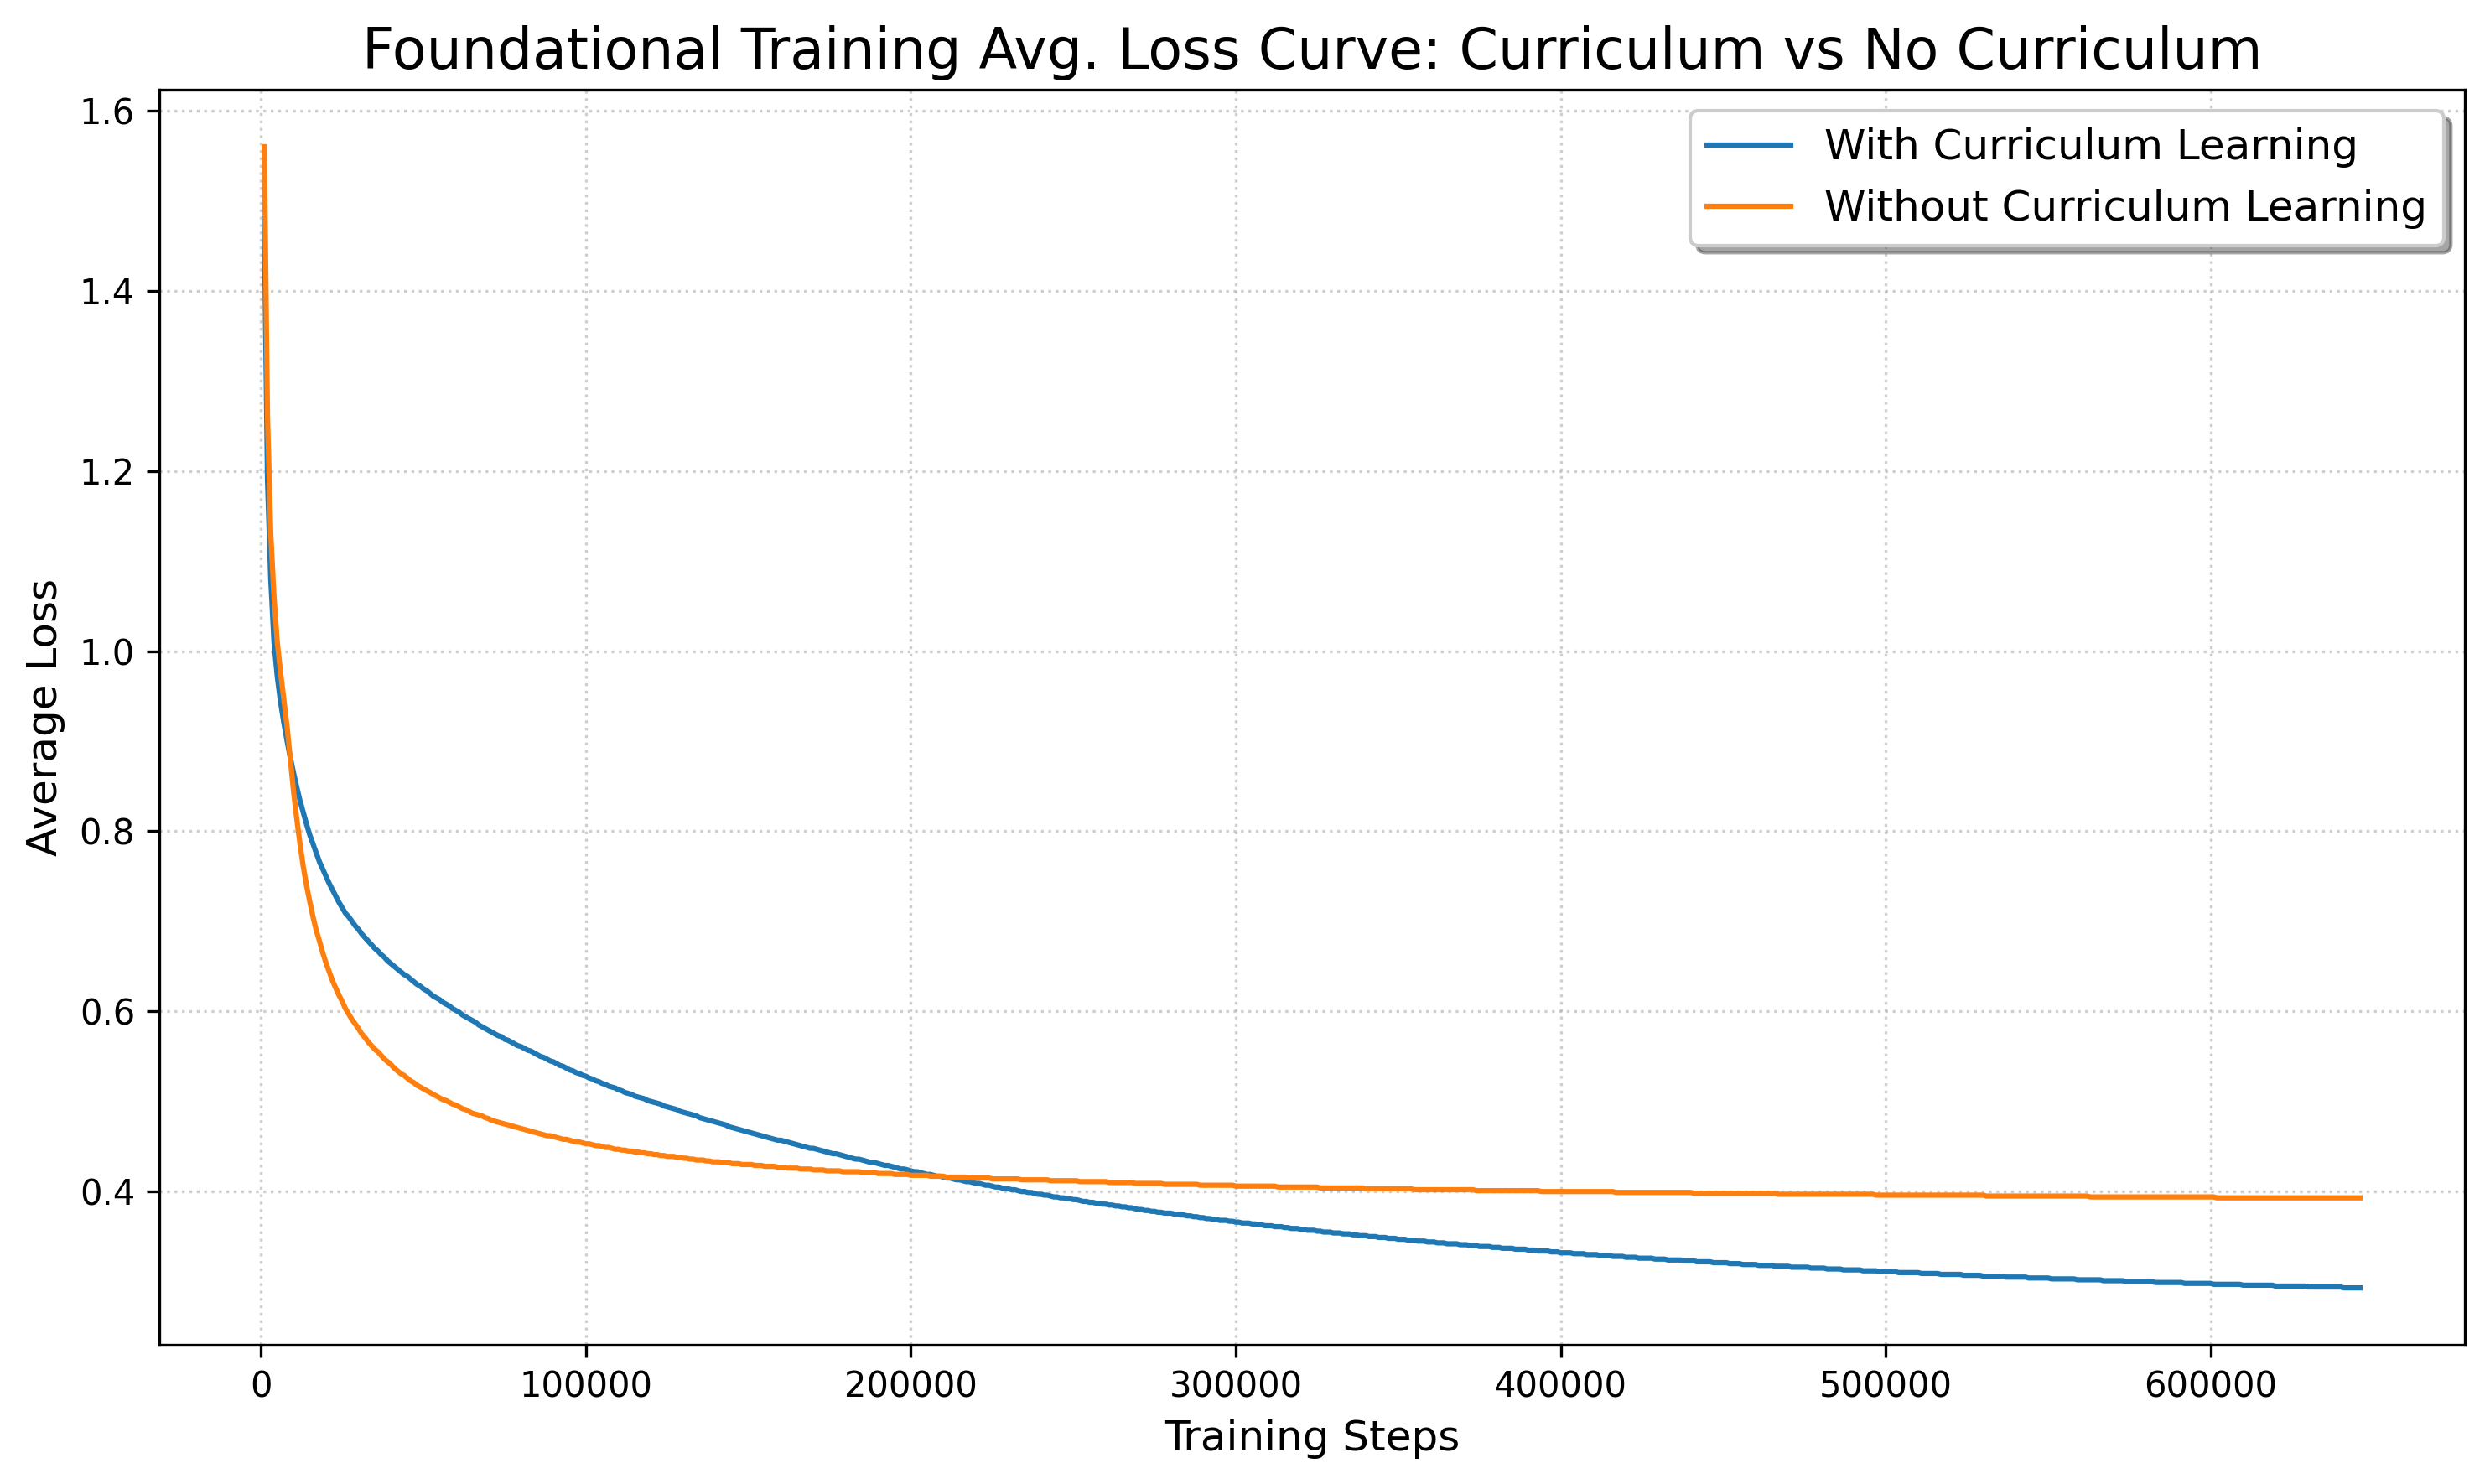

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Foundational Training Data
try:
    df_found_curr = pd.read_csv('evaluation_results/foundation_training_curve.csv', names=['step', 'loss'])
    df_found_nocurr = pd.read_csv('evaluation_results/nocurr_foundation_training_curve.csv', names=['step', 'loss'])

    plt.figure(figsize=(10,6), dpi=300)
    plt.plot(df_found_curr['step'], df_found_curr['loss'], label='With Curriculum Learning')
    plt.plot(df_found_nocurr['step'], df_found_nocurr['loss'], label='Without Curriculum Learning')
    
    plt.title('Foundational Training Avg. Loss Curve: Curriculum vs No Curriculum', fontsize=16)
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Average Loss', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=12, frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting foundational curves: {e}")

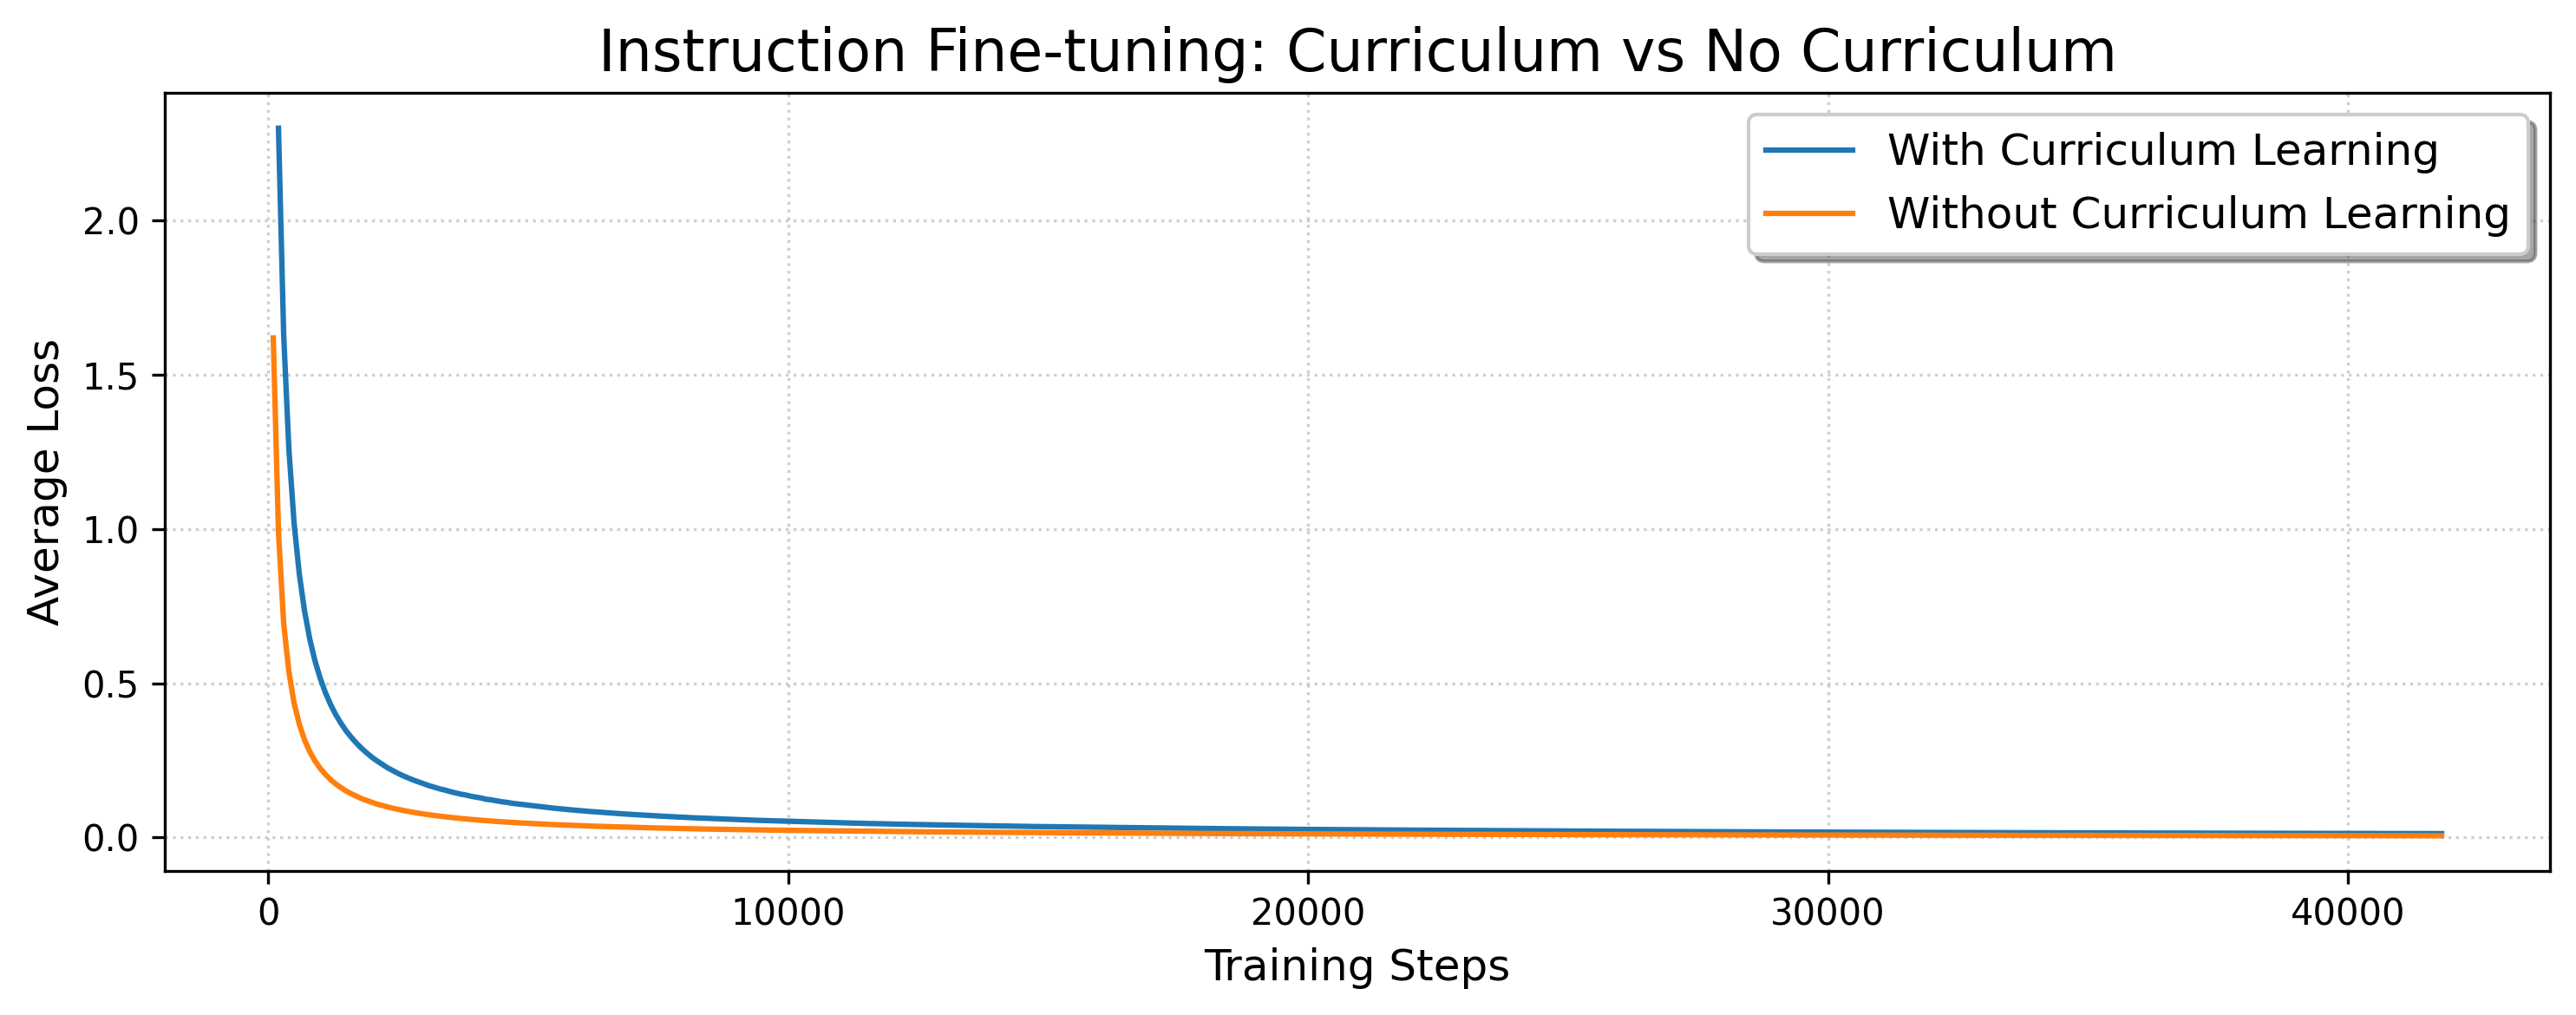

In [45]:
# Load Instruction Fine-tuning Data
try:
    df_inst_curr = pd.read_csv('evaluation_results/instruction_training_curve.csv', names=['step', 'loss'])
    df_inst_nocurr = pd.read_csv('evaluation_results/nocurr_instruction_training_curve.csv', names=['step', 'loss'])

    plt.figure(figsize=(10, 4), dpi=300)
    plt.plot(df_inst_curr['step'], df_inst_curr['loss'], label='With Curriculum Learning')
    plt.plot(df_inst_nocurr['step'], df_inst_nocurr['loss'], label='Without Curriculum Learning')
    
    plt.title('Instruction Fine-tuning: Curriculum vs No Curriculum', fontsize=16)
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Average Loss', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=12, frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting instruction curves: {e}")

## Varied Depth Evaluation
Accuracy of models across different AST depths (1-5).

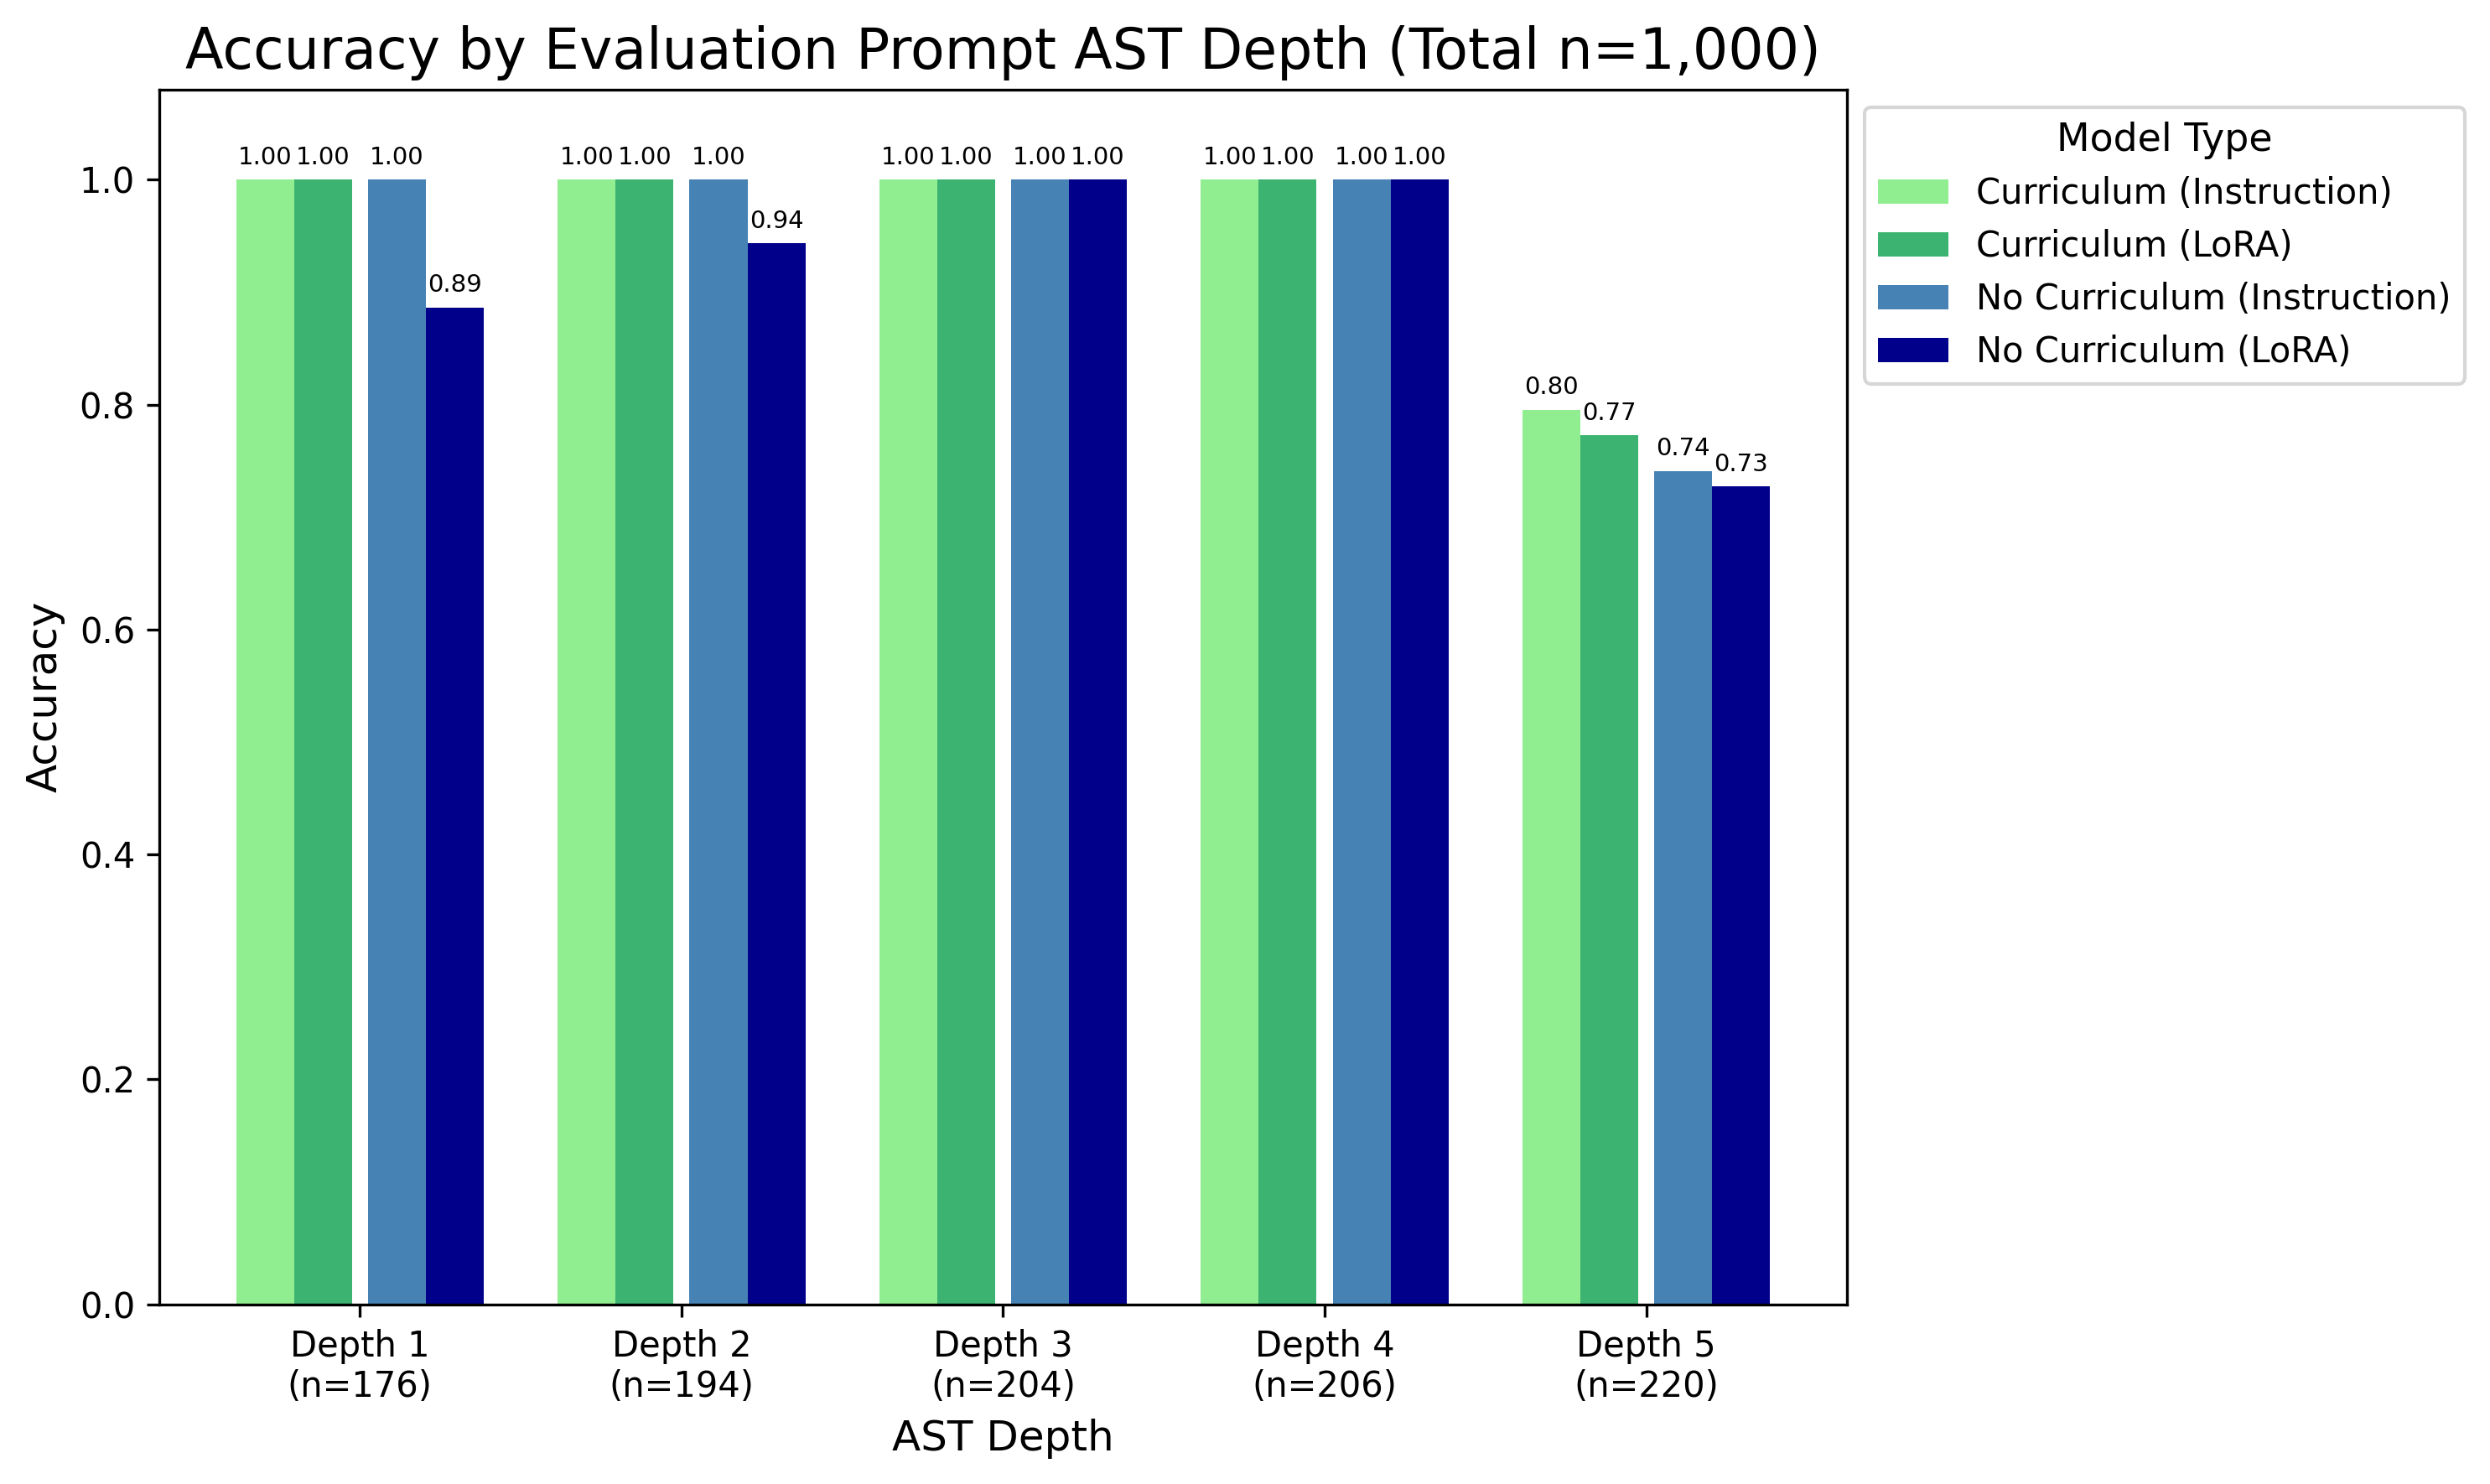

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

# Define mappings for model names (full names as requested)
model_mapping = {
    '21351022_instruction': 'Curriculum (Instruction)',
    '21351022_instruction_lora': 'Curriculum (LoRA)',
    '21351035_no_curriculum_instruction': 'No Curriculum (Instruction)',
    '21351035_no_curriculum_instruction_lora': 'No Curriculum (LoRA)'
}

# Order of models: Curriculum first, then No Curriculum
model_order = ['Curriculum (Instruction)', 'Curriculum (LoRA)', 'No Curriculum (Instruction)', 'No Curriculum (LoRA)']

# 1. Load varied depth data
varied_csvs = glob.glob('evaluation_results/varied_depth/*/*.csv')
# 2. Load full depth data (which is all Depth 5)
full_csvs = glob.glob('evaluation_results/full_depth/*/*.csv')

all_csvs = varied_csvs

df_list = []
for file in all_csvs:
    folder_name = os.path.basename(os.path.dirname(file))
    if folder_name in model_mapping:
        df = pd.read_csv(file)
        df['Model'] = model_mapping[folder_name]
        df_list.append(df)

if df_list:
    full_df = pd.concat(df_list, ignore_index=True)
    
    # Calculate accuracy and count per depth per model
    agg_df = full_df.groupby(['Depth', 'Model']).agg(
        Accuracy=('Correct', 'mean'),
        Count=('Correct', 'count')
    ).reset_index()
    
    # Pivot for plotting
    pivot_acc = agg_df.pivot(index='Depth', columns='Model', values='Accuracy')
    pivot_acc = pivot_acc.reindex(columns=model_order) # Ensure correct order
    
    # Get counts for x-axis labels
    counts = agg_df.groupby('Depth')['Count'].max() 
    x_labels = [f"Depth {d}\n(n={int(counts[d])})" for d in pivot_acc.index]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    # Custom colors: Two shades of light green for Curriculum, two shades of dark blue for No Curriculum
    colors = ['#8fce00', '#2986cc', '#50e991', '#0b5394']
    # actually let's make it two shades of green, then two shades of blue:
    colors = ['#50e991', '#8fce00', '#2986cc', '#0b5394']
    
    # We want a gap between the Inst/LoRA pairs. We can't do this directly with default pandas plot,
    # so we'll plot them manually using matplotlib bar.
    
    x = np.arange(len(pivot_acc.index)) # the label locations
    width = 0.18  # the width of the bars
    gap = 0.05    # extra gap between Curriculum / No Curriculum groups
    
    # Position for each bar group
    pos_curr_inst = x - width - gap/2 - width/2
    pos_curr_lora   = x - gap/2 - width/2
    pos_nocurr_inst = x + gap/2 + width/2
    pos_nocurr_lora = x + width + gap/2 + width/2

    bars = [
        ax.bar(pos_curr_inst, pivot_acc['Curriculum (Instruction)'], width, label='Curriculum (Instruction)', color='#90ee90'),
        ax.bar(pos_curr_lora, pivot_acc['Curriculum (LoRA)'], width, label='Curriculum (LoRA)', color='#3cb371'),
        ax.bar(pos_nocurr_inst, pivot_acc['No Curriculum (Instruction)'], width, label='No Curriculum (Instruction)', color='#4682b4'),
        ax.bar(pos_nocurr_lora, pivot_acc['No Curriculum (LoRA)'], width, label='No Curriculum (LoRA)', color='#00008b')
    ]
    
    plt.title('Accuracy by Evaluation Prompt AST Depth (Total n=1,000)', fontsize=16)
    plt.xlabel('AST Depth', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=0)
    
    # Legend outside and full names
    plt.legend(title='Model Type', fontsize=10, title_fontsize=11, loc='upper left', bbox_to_anchor=(1, 1))
    
    # y-axis limit and grid
    ax.set_ylim(0.7, 1.0)
    
    # Add value labels on top of bars
    for bar_group in bars:
        for bar in bar_group:
            height = bar.get_height()
            # Only annotate if it's within our y-limits (at least > 0.7 to avoid weird labels)
            if height > 0.0:
                ax.annotate(f"{height:.2f}",
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=7)

    # Expand y limit slightly to accommodate labels (adjust upper limit slightly so text doesn't overflow)
    ax.set_ylim(0,1.08)

    plt.tight_layout()
    plt.show()
else:
    print("No CSVs found for evaluation.")
